# Bab 4 — Regression and Prediction

Salah satu tujuan paling umum dalam statistik: *Apakah variabel X berhubungan dengan variabel Y, dan jika ya, bagaimana hubungannya? Bisakah kita memakai X untuk memprediksi Y?*

Isi notebook:
1. Simple linear regression
2. Multiple linear regression
3. Menilai model (RMSE, R², t-statistic) & cross-validation
4. Model selection & stepwise regression
5. Weighted regression
6. Prediksi: confidence vs prediction interval
7. Factor variables (dummy)
8. Menginterpretasikan regresi (multicollinearity, confounding, interaksi)
9. Regression diagnostics
10. Polynomial, spline & GAM

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import OLSInfluence, variance_inflation_factor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import cross_val_score

%matplotlib inline
sns.set_theme(style='whitegrid')

DATA_URL = 'https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/'

def load(name, **kwargs):
    local = Path('data') / name
    source = local if local.exists() else DATA_URL + name
    return pd.read_csv(source, **kwargs)

## 1. Simple Linear Regression

**Simple linear regression** memodelkan hubungan antara besaran satu variabel (Y) dengan variabel lain (X) dalam bentuk garis lurus:

$$Y = b_0 + b_1 X + e$$

Istilah:
- **Response** — variabel yang ingin diprediksi (sinonim: dependent variable, Y, target, outcome).
- **Independent variable** — variabel yang dipakai untuk memprediksi (sinonim: X, feature, predictor, attribute).
- **Intercept ($b_0$)** — nilai prediksi ketika X = 0.
- **Regression coefficient / slope ($b_1$)** — perubahan Y untuk setiap kenaikan X sebesar 1 unit.
- **Fitted values ($\hat{Y}_i$)** — nilai prediksi dari model.
- **Residuals ($e_i = Y_i - \hat{Y}_i$)** — selisih nilai observasi dengan fitted value.
- **Least squares** — metode fitting regresi dengan **meminimalkan jumlah kuadrat residual** (RSS):

$$RSS = \sum_{i=1}^{n}(Y_i - \hat{b}_0 - \hat{b}_1 X_i)^2$$

Solusinya:
$$\hat{b}_1 = \frac{\sum (X_i-\bar{X})(Y_i-\bar{Y})}{\sum (X_i-\bar{X})^2}, \qquad \hat{b}_0 = \bar{Y} - \hat{b}_1 \bar{X}$$

Contoh: `LungDisease.csv` — kapasitas paru (PEFR, *peak expiratory flow rate*) pekerja pabrik kapas vs lama paparan debu kapas (tahun).

   PEFR  Exposure
0   390         0
1   410         0
2   430         0
3   460         0
4   420         1


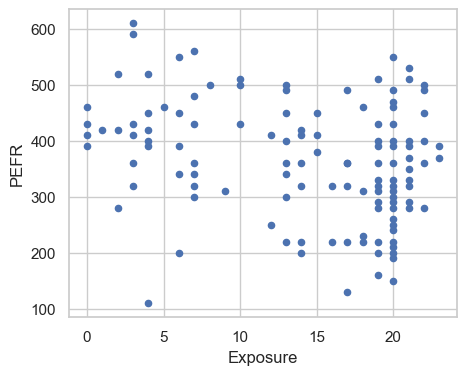

In [2]:
lung = load('LungDisease.csv')
print(lung.head())

lung.plot.scatter(x='Exposure', y='PEFR', figsize=(5, 4))
plt.show()

In [3]:
predictors = ['Exposure']
outcome = 'PEFR'

model = LinearRegression()
model.fit(lung[predictors], lung[outcome])
print(f'Intercept: {model.intercept_:.3f}')
print(f'Coefficient Exposure: {model.coef_[0]:.3f}')

# Verifikasi dengan rumus least squares manual
x, y = lung['Exposure'], lung['PEFR']
b1 = ((x - x.mean()) * (y - y.mean())).sum() / ((x - x.mean()) ** 2).sum()
b0 = y.mean() - b1 * x.mean()
print(f'Manual -> b0 = {b0:.3f}, b1 = {b1:.3f}')

Intercept: 424.583
Coefficient Exposure: -4.185
Manual -> b0 = 424.583, b1 = -4.185


Interpretasi: setiap tambahan **1 tahun** paparan debu kapas menurunkan PEFR sekitar **4.185** unit. Pekerja tanpa paparan (X = 0) diprediksi punya PEFR ≈ 424.6.

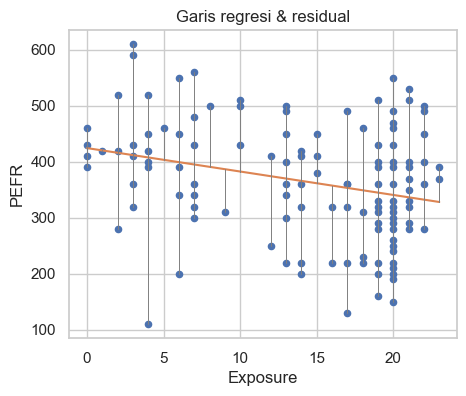

In [4]:
fitted = model.predict(lung[predictors])
residuals = lung[outcome] - fitted

fig, ax = plt.subplots(figsize=(5, 4))
lung.plot.scatter(x='Exposure', y='PEFR', ax=ax)
ax.plot(lung.Exposure, fitted, color='C1')
# gambar residual sebagai garis vertikal
for x_i, y_i, f_i in zip(lung.Exposure, lung.PEFR, fitted):
    ax.plot((x_i, x_i), (y_i, f_i), color='grey', lw=0.7)
ax.set_title('Garis regresi & residual')
plt.show()

> **Prediction vs explanation**: Secara historis regresi dipakai untuk *menjelaskan* hubungan (profiling). Di data science, regresi juga banyak dipakai untuk *memprediksi* outcome individual pada data baru. Hati-hati: regresi sendiri **tidak membuktikan kausalitas**.

## 2. Multiple Linear Regression

Jika ada banyak prediktor:

$$Y = b_0 + b_1 X_1 + b_2 X_2 + \dots + b_p X_p + e$$

Setiap koefisien $b_j$ diinterpretasikan sebagai perubahan Y per kenaikan 1 unit $X_j$, **dengan asumsi variabel lain tetap** (*holding all other variables constant*).

Contoh: `house_sales.csv` — data penjualan rumah di King County, Washington. Tujuannya memprediksi harga jual (`AdjSalePrice`).

In [5]:
house = load('house_sales.csv', sep='\t')
subset = ['AdjSalePrice', 'SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']
print(house.shape)
house[subset].head()

(22687, 22)


,AdjSalePrice,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade
1,300805.0,2400,9373,3.00,6,7
2,1076162.0,3764,20156,3.75,4,10
3,761805.0,2060,26036,1.75,4,8
4,442065.0,3200,8618,3.75,5,7
5,297065.0,1720,8620,1.75,4,7


In [6]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']
outcome = 'AdjSalePrice'

house_lm = LinearRegression()
house_lm.fit(house[predictors], house[outcome])

print(f'Intercept: {house_lm.intercept_:.3f}')
for name, coef in zip(predictors, house_lm.coef_):
    print(f'  {name:15s}: {coef:12.3f}')

Intercept: -521871.368
  SqFtTotLiving  :      228.831
  SqFtLot        :       -0.060
  Bathrooms      :   -19442.840
  Bedrooms       :   -47769.955
  BldgGrade      :   106106.963


Contoh interpretasi: menambah **1 sq ft** luas bangunan menaikkan prediksi harga sekitar **$229**, dengan asumsi variabel lain tetap. Menambah 1000 sq ft → sekitar $229.000.

## 3. Menilai Model

- **Root Mean Squared Error (RMSE)** — akar dari rata-rata kuadrat error; metrik paling umum untuk membandingkan model regresi:
  $$RMSE = \sqrt{\frac{\sum (y_i - \hat{y}_i)^2}{n}}$$
- **Residual Standard Error (RSE)** — sama seperti RMSE tetapi dibagi *degrees of freedom* $(n - p - 1)$.
- **R-squared ($R^2$)** — proporsi variansi Y yang dijelaskan model (0 sampai 1):
  $$R^2 = 1 - \frac{\sum (y_i-\hat{y}_i)^2}{\sum (y_i-\bar{y})^2}$$
- **Adjusted R²** — R² yang diberi penalti untuk jumlah prediktor.
- **t-statistic** — koefisien dibagi standard error-nya; semakin besar |t|, semakin kuat bukti bahwa prediktor itu berguna. $t_b = \hat{b} / SE(\hat{b})$
- **p-value** — dari t-statistic; sering dipakai untuk menilai signifikansi prediktor.

In [7]:
fitted = house_lm.predict(house[predictors])
RMSE = np.sqrt(mean_squared_error(house[outcome], fitted))
r2 = r2_score(house[outcome], fitted)
print(f'RMSE: {RMSE:.0f}')
print(f'R2  : {r2:.4f}')

RMSE: 261220
R2  : 0.5406


In [8]:
# statsmodels memberikan ringkasan statistik lengkap (SE, t, p-value, R2, AIC, ...)
model = sm.OLS(house[outcome], sm.add_constant(house[predictors]))
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.541
Model:                            OLS   Adj. R-squared:                  0.540
Method:                 Least Squares   F-statistic:                     5338.
Date:                Mon, 28 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:05:39   Log-Likelihood:            -3.1517e+05
No. Observations:               22687   AIC:                         6.304e+05
Df Residuals:                   22681   BIC:                         6.304e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -5.219e+05   1.57e+04    -33.342

### Cross-Validation

Metrik di atas dihitung dari data yang sama yang dipakai untuk fitting (**in-sample**). Untuk menilai performa pada data baru, gunakan **holdout sample** atau **k-fold cross-validation**:

1. Sisihkan 1/k data sebagai holdout.
2. Latih model pada data sisanya.
3. Hitung metrik pada holdout.
4. Kembalikan holdout, sisihkan 1/k data berikutnya.
5. Ulangi k kali, lalu rata-ratakan hasilnya.

In [9]:
scores = cross_val_score(LinearRegression(), house[predictors], house[outcome],
                         cv=5, scoring='neg_root_mean_squared_error')
print('RMSE tiap fold:', (-scores).round(0))
print(f'RMSE rata-rata CV: {-scores.mean():.0f}')

RMSE tiap fold: [243016. 269290. 293158. 278565. 217994.]
RMSE rata-rata CV: 260405


## 4. Model Selection & Stepwise Regression

Menambah variabel **selalu** menurunkan RMSE in-sample, tapi belum tentu memperbaiki prediksi pada data baru. Prinsip **Occam's razor**: jika dua model sama baiknya, pilih yang lebih sederhana.

- **AIC (Akaike Information Criterion)** — metrik yang memberi penalti untuk jumlah parameter: $AIC = 2P + n\log(RSS/n)$. Semakin kecil semakin baik. Varian: **BIC** (penalti lebih besar), **Mallows Cp**.
- **Stepwise regression** — menambah/membuang prediktor satu per satu untuk meminimalkan AIC.
  - **Forward selection** — mulai tanpa prediktor, tambah satu per satu.
  - **Backward elimination** — mulai dengan semua prediktor, buang satu per satu.
- **Penalized regression / regularization** — alih-alih membuang variabel, koefisiennya "dikecilkan": **Ridge** (penalti L2) dan **Lasso** (penalti L1, bisa membuat koefisien tepat nol).

In [10]:
predictors_full = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade',
                   'PropertyType', 'NbrLivingUnits', 'SqFtFinBasement', 'YrBuilt',
                   'YrRenovated', 'NewConstruction']

X = pd.get_dummies(house[predictors_full], drop_first=True, dtype=int)
X['NewConstruction'] = X['NewConstruction'].astype(int)
y = house[outcome]

def aic_of(cols):
    exog = sm.add_constant(X[cols]) if cols else np.ones((len(y), 1))
    return sm.OLS(y, exog).fit().aic

def forward_selection(candidates):
    selected, best_aic = [], aic_of([])
    while True:
        scores = {c: aic_of(selected + [c]) for c in candidates if c not in selected}
        if not scores:
            break
        best_col = min(scores, key=scores.get)
        if scores[best_col] >= best_aic:
            break
        selected.append(best_col)
        best_aic = scores[best_col]
        print(f'+ {best_col:25s} AIC = {best_aic:,.0f}')
    return selected

best_vars = forward_selection(list(X.columns))
print('Variabel terpilih:', best_vars)

+ SqFtTotLiving             AIC = 633,011
+ BldgGrade                 AIC = 630,792


+ YrBuilt                   AIC = 628,228


+ Bedrooms                  AIC = 627,782


+ Bathrooms                 AIC = 627,600


+ PropertyType_Townhouse    AIC = 627,524


+ SqFtFinBasement           AIC = 627,523


+ PropertyType_Single Family AIC = 627,523


Variabel terpilih: ['SqFtTotLiving', 'BldgGrade', 'YrBuilt', 'Bedrooms', 'Bathrooms', 'PropertyType_Townhouse', 'SqFtFinBasement', 'PropertyType_Single Family']


In [11]:
best_model = LinearRegression().fit(X[best_vars], y)
print(pd.Series(best_model.coef_, index=best_vars).round(2))

SqFtTotLiving                    199.28
BldgGrade                     137159.56
YrBuilt                        -3565.42
Bedrooms                      -51947.38
Bathrooms                      42396.16
PropertyType_Townhouse         84479.16
SqFtFinBasement                    7.05
PropertyType_Single Family     22912.06
dtype: float64


Perhatikan: koefisien `Bedrooms` **negatif**! Menambah kamar tidur menurunkan harga? Ini dibahas di bagian *correlated predictors* di bawah.

Regularization dengan Ridge & Lasso (prediktor perlu distandarkan agar penaltinya adil):

In [12]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

for name, reg in [('OLS', LinearRegression()), ('Ridge', Ridge(alpha=10)),
                  ('Lasso', Lasso(alpha=5000, max_iter=10_000))]:
    pipe = make_pipeline(StandardScaler(), reg)
    cv = cross_val_score(pipe, X, y, cv=5, scoring='neg_root_mean_squared_error')
    pipe.fit(X, y)
    n_zero = (np.abs(pipe[-1].coef_) < 1e-6).sum()
    print(f'{name:6s} CV RMSE = {-cv.mean():,.0f}   koefisien nol = {n_zero}')

OLS    CV RMSE = 245,132   koefisien nol = 0


Ridge  CV RMSE = 245,127   koefisien nol = 0


Lasso  CV RMSE = 245,305   koefisien nol = 5


## 5. Weighted Regression

**Weighted regression** memberi bobot berbeda pada tiap record saat fitting. Berguna ketika:
- Beberapa observasi punya varians berbeda (*inverse-variance weighting*).
- Data teragregasi, di mana tiap baris mewakili jumlah kasus berbeda.

Contoh: penjualan rumah lama kurang relevan dibanding penjualan terbaru. Kita beri bobot = tahun penjualan − 2005, sehingga penjualan terbaru lebih berpengaruh.

In [13]:
house['Year'] = pd.to_datetime(house['DocumentDate']).dt.year
house['Weight'] = house['Year'] - 2005

house_wt = LinearRegression()
house_wt.fit(house[predictors], house[outcome], sample_weight=house['Weight'])

pd.DataFrame({'predictor': predictors,
              'house_lm': house_lm.coef_,
              'house_wt': house_wt.coef_}).round(2)

,predictor,house_lm,house_wt
0,SqFtTotLiving,228.83,245.02
1,SqFtLot,-0.06,-0.29
2,Bathrooms,-19442.84,-26085.97
3,Bedrooms,-47769.96,-53608.88
4,BldgGrade,106106.96,115242.43


## 6. Prediksi dengan Regresi: Confidence vs Prediction Interval

- **Confidence interval** — ketidakpastian di sekitar **koefisien regresi** atau **rata-rata prediksi** (mean response).
- **Prediction interval** — ketidakpastian di sekitar **nilai prediksi individual**. Selalu **lebih lebar** dari confidence interval karena juga memperhitungkan error individual (*noise*).
- **Extrapolation** — memakai model di luar rentang data yang dipakai untuk fitting. Berbahaya! Misalnya memprediksi harga lahan kosong (SqFtTotLiving = 0) dengan model di atas akan menghasilkan harga negatif.

Contoh: rumah 2.500 sq ft, lot 5.000 sq ft, 2 kamar mandi, 3 kamar tidur, grade 8.

In [14]:
new_house = pd.DataFrame({'SqFtTotLiving': [2500], 'SqFtLot': [5000], 'Bathrooms': [2],
                          'Bedrooms': [3], 'BldgGrade': [8]})
pred = results.get_prediction(sm.add_constant(new_house, has_constant='add'))
pred.summary_frame(alpha=0.05)[['mean', 'mean_ci_lower', 'mean_ci_upper',
                                 'obs_ci_lower', 'obs_ci_upper']].round(0)

,mean,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,716563.0,710926.0,722200.0,204455.0,1228671.0


`mean_ci_*` = **confidence interval** rata-rata harga rumah dengan karakteristik tersebut; `obs_ci_*` = **prediction interval** harga satu rumah — jauh lebih lebar.

Confidence interval koefisien juga bisa dihitung dengan **bootstrap** (resampling baris data, fit ulang, ambil persentil koefisien):

In [15]:
print('CI koefisien (rumus):')
print(results.conf_int(alpha=0.05).round(2))

boot_coefs = []
for i in range(200):
    sample = house.sample(frac=1, replace=True, random_state=i)
    boot_coefs.append(LinearRegression().fit(sample[predictors], sample[outcome]).coef_)
boot_coefs = pd.DataFrame(boot_coefs, columns=predictors)
print('CI koefisien (bootstrap):')
print(boot_coefs.quantile([0.025, 0.975]).T.round(2))

CI koefisien (rumus):
                       0          1
const         -552550.08 -491192.66
SqFtTotLiving     221.19     236.47
SqFtLot            -0.18       0.06
Bathrooms      -26548.85  -12336.83
Bedrooms       -52650.00  -42889.91
BldgGrade      101409.77  110804.16


CI koefisien (bootstrap):
                  0.025      0.975
SqFtTotLiving    209.07     248.64
SqFtLot           -0.21       0.14
Bathrooms     -28928.50  -10055.41
Bedrooms      -57197.61  -38077.67
BldgGrade      99503.04  112994.00


## 7. Factor Variables dalam Regresi

**Factor variable** = variabel kategorikal. Regresi butuh input numerik, jadi faktor harus di-*encode*:

- **Dummy variables** — variabel biner 0/1 hasil *recoding* faktor.
- **Reference coding** — satu level dijadikan **referensi** (dibuang), level lain dibandingkan terhadapnya. Paling umum di statistik. (`drop_first=True`)
- **One-hot encoding** — semua level dipertahankan. Umum di machine learning, tapi tidak cocok untuk regresi linear dengan intercept (multicollinearity).
- **Deviation coding** — tiap level dibandingkan dengan **rata-rata keseluruhan**.

Contoh: `PropertyType` punya 3 level: Multiplex, Single Family, Townhouse.

In [16]:
print(house['PropertyType'].value_counts())
print(pd.get_dummies(house['PropertyType']).head(4))                     # one-hot
print(pd.get_dummies(house['PropertyType'], drop_first=True).head(4))    # reference coding

PropertyType
Single Family    20720
Townhouse         1710
Multiplex          257
Name: count, dtype: int64
   Multiplex  Single Family  Townhouse
1       True          False      False
2      False           True      False
3      False           True      False
4      False           True      False
   Single Family  Townhouse
1          False      False
2           True      False
3           True      False
4           True      False


In [17]:
X_pt = pd.get_dummies(house[predictors + ['PropertyType']], drop_first=True, dtype=int)
house_lm_factor = LinearRegression().fit(X_pt, house[outcome])
print(f'Intercept: {house_lm_factor.intercept_:.2f}')
print(pd.Series(house_lm_factor.coef_, index=X_pt.columns).round(2))

Intercept: -446841.37
SqFtTotLiving                    223.37
SqFtLot                           -0.07
Bathrooms                     -15979.01
Bedrooms                      -50889.73
BldgGrade                     109416.31
PropertyType_Single Family    -84678.22
PropertyType_Townhouse       -115121.98
dtype: float64


Level referensi = **Multiplex**. Koefisien `PropertyType_Single Family` berarti selisih harga rumah Single Family dibanding Multiplex (dengan variabel lain tetap).

### Factor dengan banyak level
`ZipCode` punya ~80 level — terlalu banyak untuk dijadikan dummy semua. Salah satu solusi dari buku: kelompokkan zip code berdasarkan **median residual** model awal menjadi 5 grup (`ZipGroup`). Ini sekaligus contoh **ordered factor**.

In [18]:
print('Jumlah zip code unik:', house['ZipCode'].nunique())

residual = house[outcome] - house_lm.predict(house[predictors])
zip_stats = (residual.groupby(house['ZipCode'])
             .agg(['median', 'count'])
             .sort_values('median'))
zip_stats['cum_count'] = zip_stats['count'].cumsum()
zip_stats['ZipGroup'] = pd.qcut(zip_stats['cum_count'], 5, labels=False)

house = house.drop(columns='ZipGroup', errors='ignore').join(zip_stats['ZipGroup'], on='ZipCode')
house['ZipGroup'] = house['ZipGroup'].astype('category')
print(house['ZipGroup'].value_counts().sort_index())

Jumlah zip code unik: 80
ZipGroup
0    4733
1    3602
2    4607
3    4279
4    5466
Name: count, dtype: int64


## 8. Menginterpretasikan Persamaan Regresi

- **Correlated variables** — ketika prediktor saling berkorelasi tinggi, koefisien individual sulit diinterpretasikan.
- **Multicollinearity** — kasus ekstrem dari correlated variables: satu prediktor bisa dinyatakan sebagai kombinasi linear prediktor lain. Membuat solusi regresi tidak stabil. Diukur dengan **VIF (Variance Inflation Factor)**; VIF > 5–10 dianggap bermasalah.
- **Confounding variable** — prediktor penting yang **tidak dimasukkan** ke model, sehingga hubungan yang terlihat menjadi palsu (*spurious*).
- **Main effects** — hubungan antara prediktor dan outcome, terlepas dari variabel lain.
- **Interactions** — hubungan saling bergantung antara dua atau lebih prediktor terhadap outcome.

### Correlated predictors
Kenapa koefisien Bedrooms negatif? Karena `Bedrooms` berkorelasi dengan `SqFtTotLiving` dan `Bathrooms`. Untuk rumah dengan **luas yang sama**, lebih banyak kamar berarti kamar-kamarnya lebih kecil → kurang diminati. Jika variabel luas & kamar mandi dikeluarkan, koefisien Bedrooms menjadi positif.

In [19]:
print(house[['SqFtTotLiving', 'Bathrooms', 'Bedrooms']].corr().round(3))

preds_small = ['Bedrooms', 'BldgGrade', 'SqFtLot']
m = LinearRegression().fit(house[preds_small], house[outcome])
print('Koefisien tanpa SqFtTotLiving & Bathrooms:')
print(pd.Series(m.coef_, index=preds_small).round(2))

               SqFtTotLiving  Bathrooms  Bedrooms
SqFtTotLiving          1.000      0.764     0.600
Bathrooms              0.764      1.000     0.538
Bedrooms               0.600      0.538     1.000
Koefisien tanpa SqFtTotLiving & Bathrooms:
Bedrooms      30948.98
BldgGrade    210002.38
SqFtLot           0.51
dtype: float64


In [20]:
# Variance Inflation Factor
Xv = sm.add_constant(house[predictors])
vif = pd.Series([variance_inflation_factor(Xv.values, i) for i in range(1, Xv.shape[1])],
                index=predictors, name='VIF')
vif.round(2)

SqFtTotLiving    4.22
SqFtLot          1.05
Bathrooms        2.58
Bedrooms         1.69
BldgGrade        2.66
Name: VIF, dtype: float64

### Confounding variable
Lokasi (`ZipGroup`) adalah confounder penting untuk harga rumah. Setelah dimasukkan, koefisien variabel lain berubah cukup banyak.

In [21]:
cols = predictors + ['ZipGroup']
X_conf = pd.get_dummies(house[cols], drop_first=True, dtype=int)
confounding_lm = LinearRegression().fit(X_conf, house[outcome])
print(f'Intercept: {confounding_lm.intercept_:.2f}')
print(pd.Series(confounding_lm.coef_, index=X_conf.columns).round(2))

Intercept: -624094.13
SqFtTotLiving       228.85
SqFtLot               0.49
Bathrooms        -10003.79
Bedrooms         -36587.66
BldgGrade         92449.58
ZipGroup_1        52358.54
ZipGroup_2       110676.45
ZipGroup_3       170739.21
ZipGroup_4       329777.33
dtype: float64


### Interaksi
Apakah efek luas bangunan terhadap harga **sama** di semua lokasi? Kemungkinan tidak: di lokasi mahal, tiap sq ft tambahan lebih berharga. Dalam formula statsmodels, `A * B` berarti main effect A, main effect B, dan interaksi A:B.

In [22]:
model_int = smf.ols('AdjSalePrice ~ SqFtTotLiving * ZipGroup + SqFtLot + Bathrooms '
                    '+ Bedrooms + BldgGrade + PropertyType', data=house).fit()
coefs = model_int.params
print(coefs[coefs.index.str.contains('SqFtTotLiving')].round(2))

SqFtTotLiving                  114.77
SqFtTotLiving:ZipGroup[T.1]     32.60
SqFtTotLiving:ZipGroup[T.2]     41.78
SqFtTotLiving:ZipGroup[T.3]     69.34
SqFtTotLiving:ZipGroup[T.4]    226.68
dtype: float64


Slope `SqFtTotLiving` di ZipGroup 0 (termurah) ≈ nilai koefisien utama; di ZipGroup 4 (termahal) slope = koefisien utama + koefisien interaksi `SqFtTotLiving:ZipGroup[T.4]` — kira-kira **dua kali lipat** atau lebih.

## 9. Regression Diagnostics

Untuk *explanatory modeling*, kita perlu memeriksa apakah asumsi regresi terpenuhi.

- **Standardized residuals** — residual dibagi standard error residual. Nilai |r| > 2.5 atau 3 → kandidat **outlier**.
- **Outlier** — record (atau outcome) yang jauh dari sebagian besar data.
- **Influential value** — record yang, bila ada/tidak ada, mengubah persamaan regresi secara signifikan.
- **Leverage** — derajat pengaruh satu record terhadap persamaan regresi. Diukur dengan **hat-value**; nilai di atas $2(P+1)/n$ menandakan leverage tinggi.
- **Cook's distance** — gabungan leverage dan ukuran residual; nilai di atas $4/(n-P-1)$ berpengaruh besar.
- **Non-normal residuals** — biasanya tidak masalah untuk prediksi, tetapi memengaruhi validitas uji signifikansi.
- **Heteroskedasticity** — ketika varians residual **tidak konstan** di sepanjang rentang prediksi.
- **Partial residual plot** — plot untuk memvisualisasikan hubungan antara outcome dan satu prediktor (setelah memperhitungkan prediktor lain). Membantu mendeteksi **non-linearitas**.

Kita pakai subset rumah di zip code 98105.

In [23]:
house_98105 = house.loc[house['ZipCode'] == 98105].copy()
result_98105 = sm.OLS(house_98105[outcome],
                      sm.add_constant(house_98105[predictors])).fit()

influence = OLSInfluence(result_98105)
sresiduals = influence.resid_studentized_internal
print('Standardized residual terkecil:', sresiduals.min().round(3))
outlier = house_98105.loc[sresiduals.idxmin(), :]
print('AdjSalePrice outlier:', outlier[outcome])
print(outlier[predictors])

Standardized residual terkecil: -4.327
AdjSalePrice outlier: 119748.0
SqFtTotLiving    2900
SqFtLot          7276
Bathrooms         3.0
Bedrooms            6
BldgGrade           7
Name: 24333, dtype: object


Rumah ini dijual jauh di bawah prediksi. Setelah diteliti (di buku), ternyata transaksinya hanya penjualan **sebagian** kepemilikan — bukan transaksi normal. Outlier seperti ini sebaiknya dibuang dari data training.

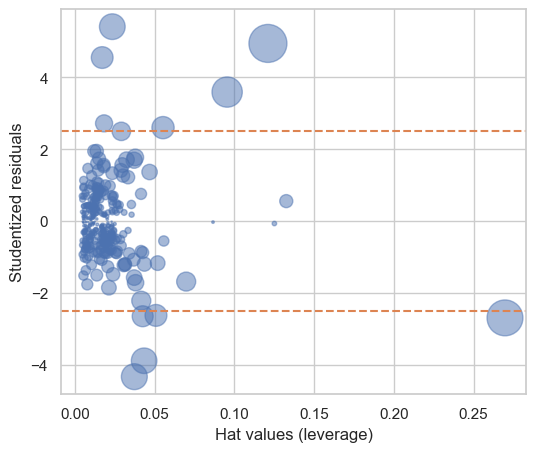

,semua data,tanpa influential
const,-772549.9,-647137.1
SqFtTotLiving,209.6,230.1
SqFtLot,38.9,33.1
Bathrooms,2282.3,-16131.9
Bedrooms,-26320.3,-22887.9
BldgGrade,130000.1,114870.6


In [24]:
# Influence plot: hat-value vs standardized residual, ukuran titik = Cook's distance
cooks_d = influence.cooks_distance[0]
hat_values = influence.hat_matrix_diag

fig, ax = plt.subplots(figsize=(6, 5))
ax.axhline(-2.5, linestyle='--', color='C1')
ax.axhline(2.5, linestyle='--', color='C1')
ax.scatter(hat_values, sresiduals, s=1000 * np.sqrt(cooks_d), alpha=0.5)
ax.set_xlabel('Hat values (leverage)')
ax.set_ylabel('Studentized residuals')
plt.show()

# Bandingkan koefisien dengan & tanpa titik berpengaruh
mask = cooks_d < 0.08
result_clean = sm.OLS(house_98105.loc[mask, outcome],
                      sm.add_constant(house_98105.loc[mask, predictors])).fit()
pd.DataFrame({'semua data': result_98105.params,
              'tanpa influential': result_clean.params}).round(1)

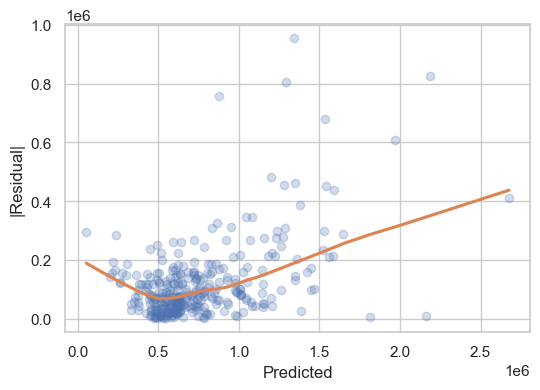

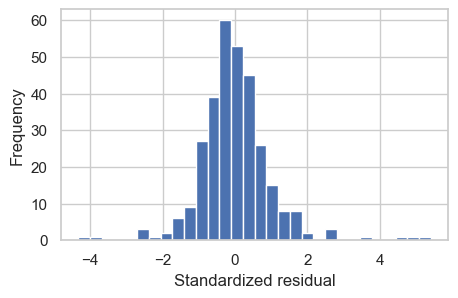

In [25]:
# Heteroskedasticity: plot |residual| vs fitted value
fig, ax = plt.subplots(figsize=(6, 4))
sns.regplot(x=result_98105.fittedvalues, y=np.abs(result_98105.resid),
            scatter_kws={'alpha': 0.25}, line_kws={'color': 'C1'}, lowess=True, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('|Residual|')
plt.show()

# Distribusi residual (cek normalitas)
pd.Series(sresiduals).plot.hist(bins=30, figsize=(5, 3), edgecolor='white')
plt.xlabel('Standardized residual')
plt.show()

Varians residual **membesar** untuk rumah dengan harga prediksi tinggi → tanda **heteroskedasticity**. Model kurang akurat untuk rumah mahal.

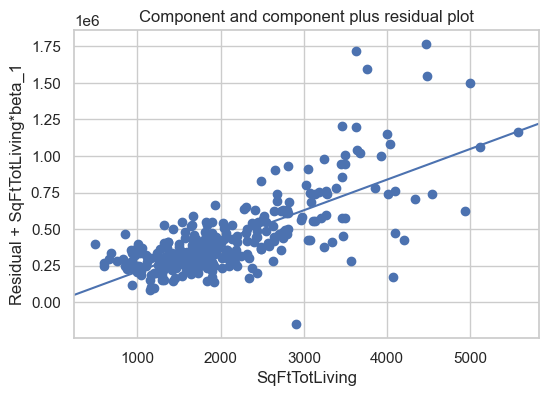

In [26]:
# Partial residual plot (component + residual plot)
fig = plt.figure(figsize=(6, 4))
sm.graphics.plot_ccpr(result_98105, 'SqFtTotLiving', ax=fig.gca())
plt.show()

Partial residual plot menunjukkan hubungan SqFtTotLiving–harga **tidak sepenuhnya linear**: model under-estimate untuk rumah kecil dan over-estimate untuk rumah sangat besar. Ini motivasi untuk bagian berikutnya.

## 10. Polynomial & Spline Regression, GAM

Hubungan antara outcome dan prediktor tidak selalu linear. Beberapa cara menangkap non-linearitas:

- **Polynomial regression** — menambah suku pangkat: $Y = b_0 + b_1X + b_2X^2 + e$.
- **Spline regression** — menyambungkan beberapa potongan polinomial secara halus di titik-titik tertentu yang disebut **knots**. Lebih fleksibel dan stabil daripada polinomial berderajat tinggi.
- **Generalized Additive Model (GAM)** — model spline dengan pemilihan knot otomatis: $Y = b_0 + f_1(X_1) + f_2(X_2) + \dots$

Catatan: model-model ini tetap disebut **linear** karena linear terhadap **koefisien**-nya, bukan terhadap X.

In [27]:
model_poly = smf.ols('AdjSalePrice ~ SqFtTotLiving + I(SqFtTotLiving**2) + '
                     'SqFtLot + Bathrooms + Bedrooms + BldgGrade', data=house_98105).fit()
print(model_poly.params.round(3))
print(f'Adj R2 linear = {result_98105.rsquared_adj:.4f}, polynomial = {model_poly.rsquared_adj:.4f}')

Intercept               -615850.842
SqFtTotLiving                 7.452
I(SqFtTotLiving ** 2)         0.039
SqFtLot                      32.559
Bathrooms                 -1435.123
Bedrooms                  -9191.944
BldgGrade                135717.060
dtype: float64
Adj R2 linear = 0.7921, polynomial = 0.8020


Adj R2 spline = 0.8074


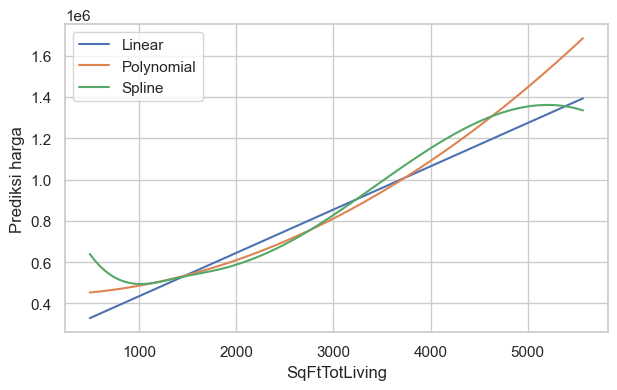

In [28]:
# Spline: B-spline kubik dengan 6 derajat kebebasan
formula = ('AdjSalePrice ~ bs(SqFtTotLiving, df=6, degree=3) + '
           'SqFtLot + Bathrooms + Bedrooms + BldgGrade')
model_spline = smf.ols(formula=formula, data=house_98105).fit()
print(f'Adj R2 spline = {model_spline.rsquared_adj:.4f}')

# Visualisasi efek SqFtTotLiving (variabel lain di-set ke median)
grid = pd.DataFrame({'SqFtTotLiving': np.linspace(house_98105.SqFtTotLiving.min(),
                                                  house_98105.SqFtTotLiving.max(), 100)})
for col in ['SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']:
    grid[col] = house_98105[col].median()

plt.figure(figsize=(7, 4))
plt.plot(grid.SqFtTotLiving, result_98105.predict(sm.add_constant(grid[predictors], has_constant='add')), label='Linear')
plt.plot(grid.SqFtTotLiving, model_poly.predict(grid), label='Polynomial')
plt.plot(grid.SqFtTotLiving, model_spline.predict(grid), label='Spline')
plt.xlabel('SqFtTotLiving')
plt.ylabel('Prediksi harga')
plt.legend()
plt.show()

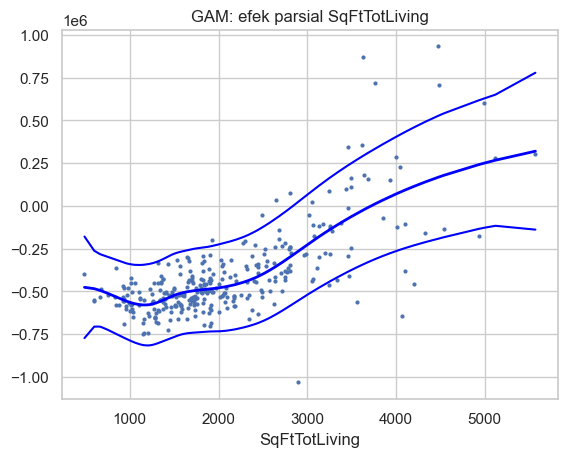

In [29]:
# GAM dengan statsmodels: smoother spline untuk SqFtTotLiving, penalti alpha mengatur kehalusan
from statsmodels.gam.api import GLMGam, BSplines

bs = BSplines(house_98105[['SqFtTotLiving']], df=[10], degree=[3])
gam = GLMGam.from_formula('AdjSalePrice ~ SqFtLot + Bathrooms + Bedrooms + BldgGrade',
                          data=house_98105, smoother=bs, alpha=np.array([1e6]))
gam_res = gam.fit()
gam_res.plot_partial(0, cpr=True)
plt.title('GAM: efek parsial SqFtTotLiving')
plt.show()

## Rangkuman Bab 4

- **Regresi linear** memodelkan Y sebagai kombinasi linear prediktor; di-fit dengan **least squares**.
- Nilai model dengan **RMSE**, **R²**, dan paling penting **cross-validation**.
- Pilih model dengan **AIC**/stepwise atau gunakan **regularization** (Ridge/Lasso).
- **Prediction interval** (individu) selalu lebih lebar dari **confidence interval** (rata-rata).
- Variabel kategorikal di-encode dengan **dummy/reference coding** (k−1 kolom).
- Hati-hati interpretasi koefisien saat ada **correlated predictors**, **multicollinearity**, **confounding**, dan **interaksi**.
- **Diagnostics**: outlier (standardized residual), influential points (leverage, Cook's distance), heteroskedasticity, partial residual plot.
- Hubungan non-linear bisa ditangkap dengan **polynomial**, **spline**, dan **GAM**.